### ATIVIDADE 1 — Experimentos com DBSCAN (variando eps e min_samples)

In [8]:
# Instalação das bibliotecas

import sys

!{sys.executable} -m pip install matplotlib seaborn scikit-learn pandas numpy scipy --quiet

print("Instalação concluída!")

Instalação concluída!



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Passo 1 — Importações e geração do dataset

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid', font_scale=1.1)

np.random.seed(42)

X_blobs, y_blobs     = make_blobs(n_samples=300, centers=3,
                                   cluster_std=1.0, random_state=42)

X_circles, y_circles = make_circles(n_samples=200, factor=0.5,
                                     noise=0.05, random_state=42)
y_circles += 3

X_moons, y_moons     = make_moons(n_samples=200, noise=0.08,
                                   random_state=42)
y_moons += 5

X      = np.vstack([X_blobs, X_circles, X_moons])
y_true = np.concatenate([y_blobs, y_circles, y_moons])

# Padronização
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset: {X_scaled.shape[0]} amostras, {X_scaled.shape[1]} features")

Dataset: 700 amostras, 2 features


#### Passo 2 — Por que K-Means FALHA nos anéis concêntricos?

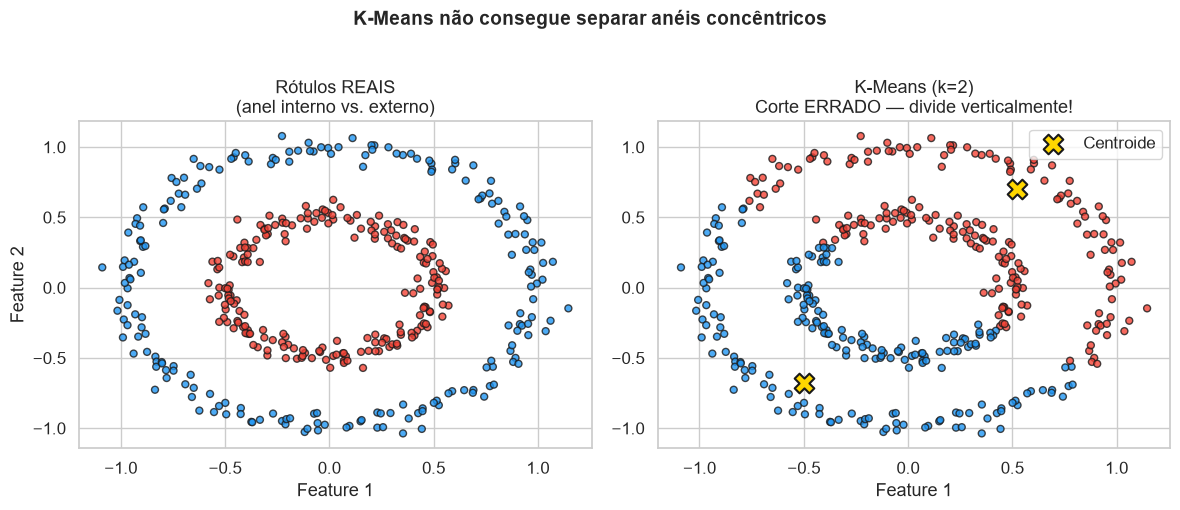

Figura salva: kmeans_falha_aneis.png


In [10]:
# Demonstração visual do fracasso do K-Means

# Dataset só com anéis
X_circ, _  = make_circles(n_samples=400, factor=0.5,
                            noise=0.05, random_state=42)
X_circ_sc  = StandardScaler().fit_transform(X_circ)

km = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_km  = km.fit_predict(X_circ_sc)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gabarito real
axes[0].scatter(X_circ[:,0], X_circ[:,1],
                c=['#2196F3' if i==0 else '#F44336' for i in _],
                edgecolors='k', s=25, alpha=0.8)
axes[0].set_title('Rótulos REAIS\n(anel interno vs. externo)', fontsize=13)
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# K-Means (2 clusters)
axes[1].scatter(X_circ[:,0], X_circ[:,1],
                c=['#2196F3' if i==0 else '#F44336' for i in labels_km],
                edgecolors='k', s=25, alpha=0.8)
# Centroides
axes[1].scatter(km.cluster_centers_[:,0],
                km.cluster_centers_[:,1],
                marker='X', s=200, c='gold', edgecolors='k',
                linewidths=1.5, zorder=5, label='Centroide')
axes[1].set_title('K-Means (k=2)\nCorte ERRADO — divide verticalmente!',
                  fontsize=13)
axes[1].set_xlabel('Feature 1')
axes[1].legend()

plt.suptitle('K-Means não consegue separar anéis concêntricos',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('kmeans_falha_aneis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva: kmeans_falha_aneis.png")

##### Por que o K-Means falha nos anéis concêntricos?

##### 1. Distância Euclidiana
O K-Means agrupa pontos minimizando a distância ao centróide.

Nos anéis concêntricos, pontos do anel **externo** podem estar tão próximos do centro quanto pontos do anel **interno**. Como consequência, os centróides tendem a convergir para regiões centrais do conjunto de dados, dificultando a separação correta dos anéis.

##### 2. Pressuposto de Convexidade
O K-Means assume que os clusters possuem formato **convexo**, aproximadamente esférico ou globular.

Entretanto, anéis concêntricos **não são convexos**. Dessa forma, o algoritmo tende a criar fronteiras lineares que cortam os anéis, separando regiões à esquerda/direita ou acima/abaixo, em vez de identificar cada anel como um grupo distinto.

##### 3. O que usar no lugar?
- ✅ **DBSCAN** – Detecta clusters de formatos arbitrários com base em densidade.
- ✅ **Spectral Clustering** – Utiliza um grafo de similaridade para identificar estruturas complexas.
- ✅ **HDBSCAN** – Extensão hierárquica do DBSCAN, mais robusta para diferentes densidades.

##### Conclusão
O K-Means funciona bem para clusters aproximadamente esféricos e separáveis por distância ao centróide. Para estruturas não convexas, como anéis concêntricos, algoritmos baseados em densidade ou grafos geralmente produzem resultados muito superiores.

#### Passo 3 — Experimentos DBSCAN (variando eps e min_samples)

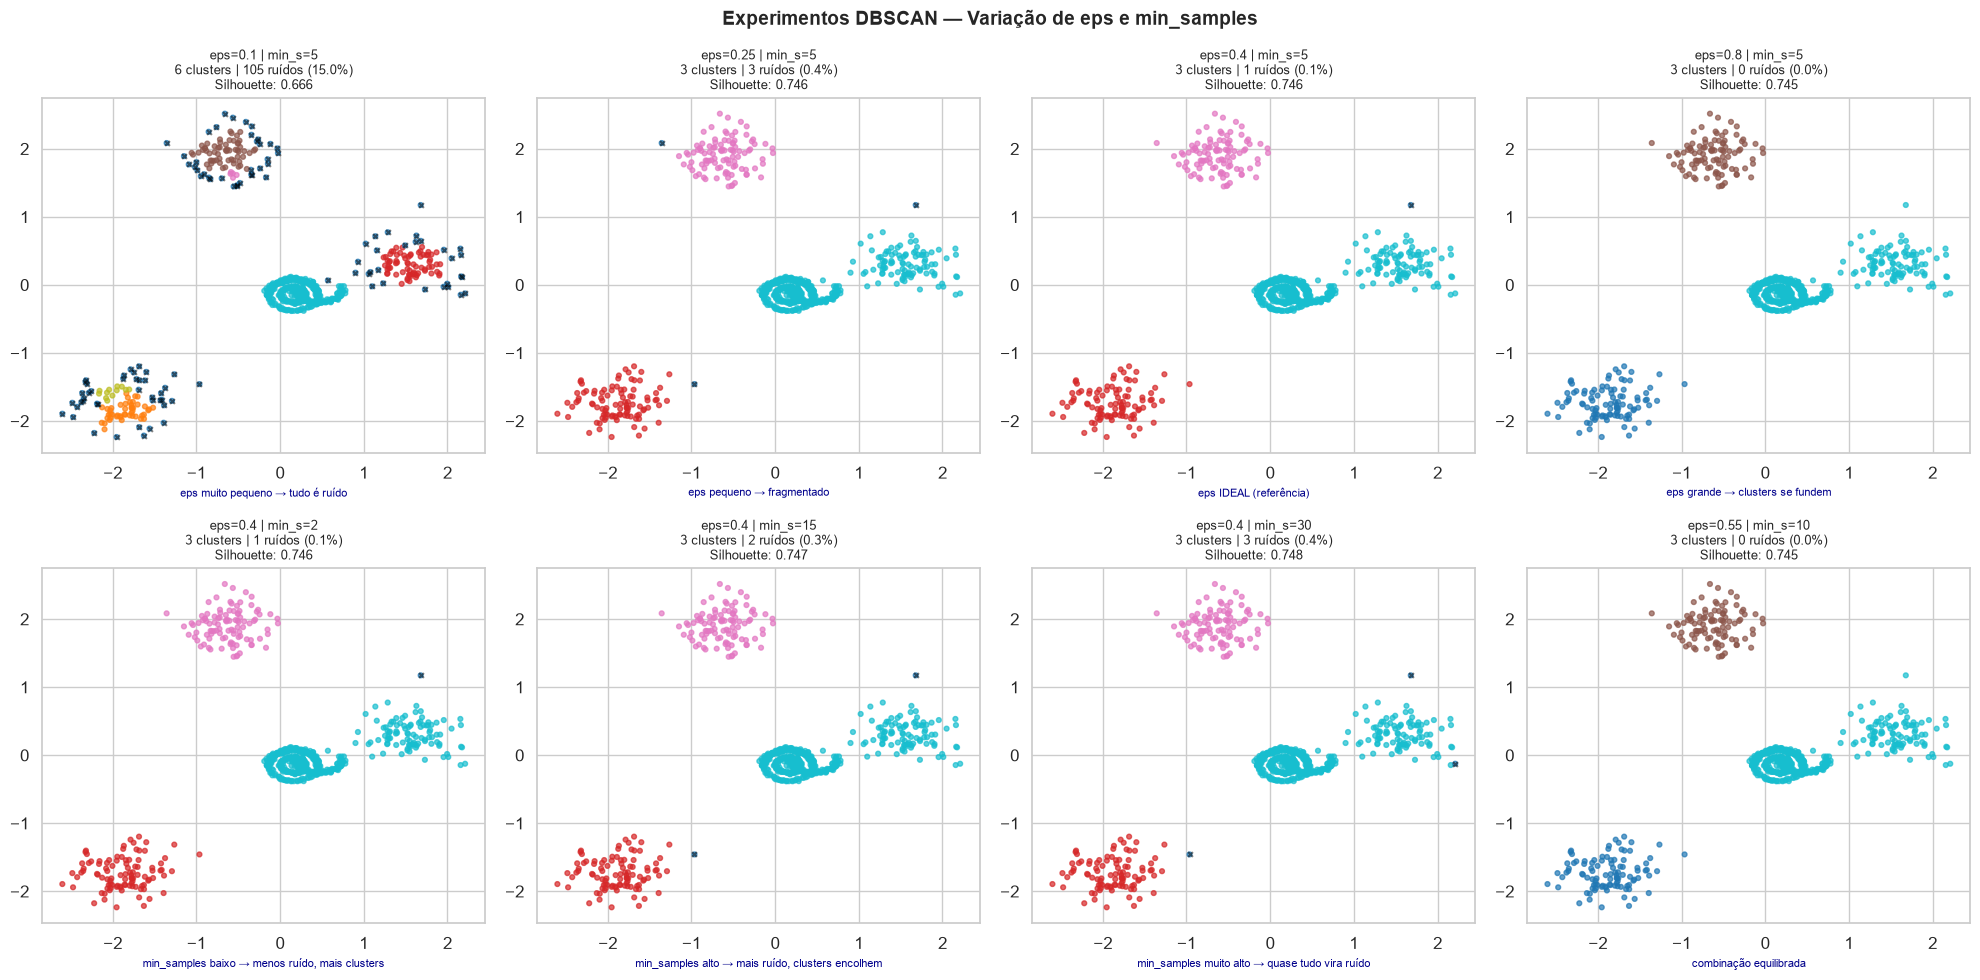

Figura salva: dbscan_experimentos.png


In [11]:
experimentos = [
    # (eps,  min_samples,  descrição)
    (0.10,  5,  "eps muito pequeno → tudo é ruído"),
    (0.25,  5,  "eps pequeno → fragmentado"),
    (0.40,  5,  "eps IDEAL (referência)"),
    (0.80,  5,  "eps grande → clusters se fundem"),
    (0.40,  2,  "min_samples baixo → menos ruído, mais clusters"),
    (0.40, 15,  "min_samples alto → mais ruído, clusters encolhem"),
    (0.40, 30,  "min_samples muito alto → quase tudo vira ruído"),
    (0.55, 10,  "combinação equilibrada"),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, (eps, min_s, desc) in enumerate(experimentos):
    labels = DBSCAN(eps=eps, min_samples=min_s).fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_ruido    = np.sum(labels == -1)
    pct_ruido  = 100 * n_ruido / len(labels)

    mask = labels != -1
    if n_clusters >= 2 and mask.sum() > n_clusters:
        sil = silhouette_score(X_scaled[mask], labels[mask])
        sil_txt = f"Silhouette: {sil:.3f}"
    else:
        sil_txt = "Silhouette: N/A"

    cores = labels.copy().astype(float)
    axes[i].scatter(X_scaled[:,0], X_scaled[:,1],
                    c=labels, cmap='tab10',
                    s=12, alpha=0.7)

    ruido_mask = labels == -1
    axes[i].scatter(X_scaled[ruido_mask, 0], X_scaled[ruido_mask, 1],
                    c='black', s=12, alpha=0.5, marker='x', label='Ruído')

    axes[i].set_title(
        f"eps={eps} | min_s={min_s}\n"
        f"{n_clusters} clusters | {n_ruido} ruídos ({pct_ruido:.1f}%)\n"
        f"{sil_txt}",
        fontsize=9
    )
    axes[i].set_xlabel(desc, fontsize=8, color='darkblue')

plt.suptitle("Experimentos DBSCAN — Variação de eps e min_samples",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dbscan_experimentos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva: dbscan_experimentos.png")

##### Passo 4 — Tabela resumo dos experimentos

In [12]:
resultados = []

for eps, min_s, desc in experimentos:
    labels     = DBSCAN(eps=eps, min_samples=min_s).fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_ruido    = int(np.sum(labels == -1))
    pct_ruido  = round(100 * n_ruido / len(labels), 1)

    mask = labels != -1
    if n_clusters >= 2 and mask.sum() > n_clusters:
        sil = round(silhouette_score(X_scaled[mask], labels[mask]), 3)
    else:
        sil = "N/A"

    resultados.append({
        "eps":         eps,
        "min_samples": min_s,
        "Clusters":    n_clusters,
        "Ruídos":      n_ruido,
        "% Ruído":     pct_ruido,
        "Silhouette":  sil,
        "Diagnóstico": desc
    })

df_res = pd.DataFrame(resultados)
print("\nTABELA RESUMO DOS EXPERIMENTOS DBSCAN")
print("=" * 80)
print(df_res.to_string(index=False))
print("=" * 80)


TABELA RESUMO DOS EXPERIMENTOS DBSCAN
 eps  min_samples  Clusters  Ruídos  % Ruído  Silhouette                                      Diagnóstico
0.10            5         6     105     15.0       0.666                 eps muito pequeno → tudo é ruído
0.25            5         3       3      0.4       0.746                        eps pequeno → fragmentado
0.40            5         3       1      0.1       0.746                           eps IDEAL (referência)
0.80            5         3       0      0.0       0.745                  eps grande → clusters se fundem
0.40            2         3       1      0.1       0.746   min_samples baixo → menos ruído, mais clusters
0.40           15         3       2      0.3       0.747 min_samples alto → mais ruído, clusters encolhem
0.40           30         3       3      0.4       0.748   min_samples muito alto → quase tudo vira ruído
0.55           10         3       0      0.0       0.745                           combinação equilibrada
